# 4. Feature Engineering

### Weather data

Calculate monthly averages per region (mean of all Jans, Febs, etc.), number of heatwave days, drought index, 

Load weather data parquet

In [74]:
import pandas as pd

In [75]:
weather = pd.read_parquet('../Data/Processed/weather_states.parquet')
weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state
36336,2016-12-15 00:00:00+00:00,0.754833,1.559000,-0.441000,0.000000,14.336861,Mecklenburg-Vorpommern
82994,2015-08-31 00:00:00+00:00,21.677498,28.052500,16.252501,0.600000,15.986593,Hamburg
5541,2018-09-01 00:00:00+00:00,15.529168,19.850000,10.950000,0.800000,13.684735,Bremen
84485,2019-09-30 00:00:00+00:00,13.631249,15.000000,11.600000,22.700005,38.046055,Hamburg
86748,2004-06-08 00:00:00+00:00,21.899498,27.687000,14.487000,0.000000,10.440000,Saarland
42713,2012-11-28 00:00:00+00:00,4.228250,5.334500,2.484500,19.500004,22.264771,Baden-Württemberg
76311,2018-11-15 00:00:00+00:00,7.622917,11.050000,5.550000,0.000000,15.683774,Brandenburg
121430,2013-05-14 00:00:00+00:00,11.353665,14.162001,9.062000,2.300000,15.484185,Hessen
8683,2005-10-06 00:00:00+00:00,14.481250,19.400000,10.450001,0.000000,16.119801,Nordrhein-Westfalen
37245,2019-06-12 00:00:00+00:00,20.335417,26.900000,15.700000,29.000000,15.876775,Mecklenburg-Vorpommern


In [76]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125680 entries, 0 to 125679
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   date                 125680 non-null  datetime64[ms, UTC]
 1   temperature_2m_mean  125680 non-null  float32            
 2   temperature_2m_max   125680 non-null  float32            
 3   temperature_2m_min   125680 non-null  float32            
 4   precipitation_sum    125680 non-null  float32            
 5   wind_speed_10m_max   125680 non-null  float32            
 6   state                125680 non-null  object             
dtypes: datetime64[ms, UTC](1), float32(5), object(1)
memory usage: 4.3+ MB


In [77]:
# Extract month and year from datetime

weather['month'] = weather['date'].dt.month
weather['year'] = weather['date'].dt.year
weather['monthyear'] = weather['month'].astype(str) + '_' + weather['year'].astype(str)
weather.sample(5)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear
73896,2012-04-05 00:00:00+00:00,5.243000,8.580501,2.680500,0.0,12.538134,Brandenburg,4,2012,4_2012
1074,2006-06-09 00:00:00+00:00,16.186750,22.218000,8.818000,0.0,10.239453,Bremen,6,2006,6_2006
38785,2023-08-30 00:00:00+00:00,15.349999,19.299999,10.950000,1.2,9.504272,Mecklenburg-Vorpommern,8,2023,8_2023
47335,2004-01-22 00:00:00+00:00,-3.031500,-1.806500,-4.006500,0.0,11.609651,Sachsen-Anhalt,1,2004,1_2004
57669,2010-11-05 00:00:00+00:00,12.301667,13.272500,11.122499,0.0,28.043051,Thüringen,11,2010,11_2010


In [78]:
monthly = weather.groupby(['state', 'year', 'month']).agg(
    temp_mean = ('temperature_2m_mean', 'mean'),
    precip_sum = ('precipitation_sum', 'sum')
).reset_index()

monthly

,state,year,month,temp_mean,precip_sum
0,Baden-Württemberg,2003,7,19.441086,56.400002
1,Baden-Württemberg,2003,8,23.156878,18.400000
2,Baden-Württemberg,2003,9,14.583459,25.699999
3,Baden-Württemberg,2003,10,6.437322,91.799995
4,Baden-Württemberg,2003,11,5.571653,58.000000
...,...,...,...,...,...
4123,Thüringen,2024,8,19.984138,72.899994
4124,Thüringen,2024,9,15.468820,88.400002
4125,Thüringen,2024,10,11.061694,62.299999
4126,Thüringen,2024,11,4.483958,53.499996


In [79]:
# Compute baseline temperature and precipitation (long-term monthly mean per Bundesland)
baseline = monthly.groupby(['state', 'month']).agg(
    baseline_temp = ('temp_mean', 'mean'),
    baseline_precip = ('precip_sum', 'mean')
).reset_index()

baseline


,state,month,baseline_temp,baseline_precip
0,Baden-Württemberg,1,0.888582,73.585716
1,Baden-Württemberg,2,1.658827,58.023811
2,Baden-Württemberg,3,4.780743,60.757145
3,Baden-Württemberg,4,9.264582,61.628571
4,Baden-Württemberg,5,13.113695,91.942856
...,...,...,...,...
187,Thüringen,8,18.361685,84.522728
188,Thüringen,9,14.538055,62.849998
189,Thüringen,10,10.015421,59.663635
190,Thüringen,11,5.154050,56.386364


In [80]:
# Calculate flood risk as n days per month with heavy rain based on regional thresholds
# NB - threshold for heavy rain can differ between regions 
# (some regions may have ecological features better able to deal with more rain)

thresholds = weather.groupby(['state','month'])['precipitation_sum'].quantile(0.95).reset_index()
thresholds = thresholds.rename(columns={'precipitation_sum':'rain_thresh'})

weather = weather.merge(thresholds, on=['state','month'])

weather['heavy_rain'] = (weather['precipitation_sum'] > 
                                     weather['rain_thresh']).astype(int)

weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
98858,2016-02-01 00:00:00+00:00,8.167167,10.613000,4.913000,2.3,32.759998,Niedersachsen,2,2016,2_2016,8.935000,0
78333,2024-05-29 00:00:00+00:00,16.204165,21.850000,10.650000,1.5,22.734219,Brandenburg,5,2024,5_2024,8.750000,0
94187,2024-10-20 00:00:00+00:00,11.979165,17.600000,7.250000,0.0,16.263872,Saarland,10,2024,10_2024,12.695001,0
97086,2011-03-27 00:00:00+00:00,3.269250,8.813000,-2.387000,0.0,7.928178,Niedersachsen,3,2011,3_2011,7.900000,0
64620,2008-05-15 00:00:00+00:00,15.435085,21.245501,8.545500,0.0,10.895576,Berlin,5,2008,5_2008,9.150001,0
95405,2006-08-19 00:00:00+00:00,19.629667,24.363001,15.313000,1.5,12.181625,Niedersachsen,8,2006,8_2006,10.294999,0
71775,2006-06-15 00:00:00+00:00,22.472166,27.130499,16.280499,0.4,9.339208,Brandenburg,6,2006,6_2006,7.854999,0
80703,2009-05-23 00:00:00+00:00,12.975418,17.652500,8.652500,0.0,20.380579,Hamburg,5,2009,5_2009,10.650000,0
87839,2007-06-04 00:00:00+00:00,18.568251,22.837000,14.137000,0.4,12.538134,Saarland,6,2007,6_2007,11.455001,0
64164,2007-02-14 00:00:00+00:00,5.747583,7.795500,4.095500,0.1,16.923830,Berlin,2,2007,2_2007,6.500000,0


In [81]:
weather[weather['heavy_rain']==1].sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
109504,2023-09-23 00:00:00+00:00,13.239583,16.350000,11.900000,13.600001,21.422270,Schleswig-Holstein,9,2023,9_2023,10.019999,1
104034,2008-10-01 00:00:00+00:00,9.886250,11.067500,9.267500,17.900002,30.096085,Schleswig-Holstein,10,2008,10_2008,10.200001,1
64200,2007-03-22 00:00:00+00:00,1.937167,2.945500,1.195500,18.700001,19.513195,Berlin,3,2007,3_2007,7.000000,1
92360,2019-10-20 00:00:00+00:00,13.706250,16.600000,11.400000,16.499998,12.101570,Saarland,10,2019,10_2019,12.695001,1
40815,2007-09-18 00:00:00+00:00,12.047000,14.984500,7.734500,16.400002,20.620806,Baden-Württemberg,9,2007,9_2007,9.910000,1
115354,2018-03-28 00:00:00+00:00,6.222916,10.750000,1.700000,9.800000,21.674870,Bayern,3,2018,3_2018,7.799999,1
80007,2007-06-27 00:00:00+00:00,12.119167,13.852500,10.452500,11.400002,35.538033,Hamburg,6,2007,6_2007,10.655001,1
109235,2022-12-28 00:00:00+00:00,6.643750,8.300000,4.600000,13.300000,29.793125,Schleswig-Holstein,12,2022,12_2022,9.900001,1
2979,2011-08-27 00:00:00+00:00,16.251331,18.668001,13.318000,21.300003,15.778518,Bremen,8,2011,8_2011,9.500001,1
87867,2007-07-02 00:00:00+00:00,16.659918,19.187000,15.037001,12.099998,22.171440,Saarland,7,2007,7_2007,11.495000,1


In [82]:
# aggregate mean monthly temp, max monthly temp, precipitation sum per month per Bundesland

weather_monthly = weather.groupby(['state', 'monthyear']).agg(
    year = ('year', 'min'),
    month = ('month', 'min'),
    mean_temp = ('temperature_2m_mean', 'mean'),
    max_temp = ('temperature_2m_max', 'max'),
    total_precip = ('precipitation_sum', 'sum'),
    n_hot_days=('temperature_2m_max', lambda x: (x > 30).sum()),
    heavy_rain_days=('heavy_rain','sum')
).reset_index()

weather_monthly.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days
1997,Mecklenburg-Vorpommern,6_2024,2024,6,16.298195,28.000000,88.899994,0,2
978,Brandenburg,7_2015,2015,7,19.872839,35.130501,73.300003,4,1
3669,Schleswig-Holstein,12_2016,2016,12,4.780807,10.467500,33.099998,0,0
769,Berlin,9_2020,2020,9,15.828889,30.250000,58.500000,1,2
3017,Saarland,6_2012,2012,6,15.858042,27.386999,111.300003,0,3
55,Baden-Württemberg,12_2014,2014,12,2.411046,10.334500,67.800003,0,1
2364,Nordrhein-Westfalen,11_2023,2023,11,6.154806,14.215500,159.500000,0,3
672,Berlin,5_2010,2010,5,11.360755,20.395500,102.099998,0,4
3263,Sachsen,5_2021,2021,5,10.461358,26.000000,115.500000,0,3
1989,Mecklenburg-Vorpommern,6_2016,2016,6,17.666014,29.359001,65.000000,0,3


In [83]:
# Merge baseline back to weather df
weather_monthly = weather_monthly.merge(baseline, on=['state', 'month'])

# Compute anomaly 
# for precip - calculate relative anomaly, e.g. -0.4 = 40% drier than normal
# for temp - stick with original scale (20C is not really "100% hotter" than 10C)
weather_monthly['temp_anomaly'] = (weather_monthly['mean_temp'] - weather_monthly['baseline_temp'])
weather_monthly['precip_prop_anomaly'] = (weather_monthly['total_precip'] - weather_monthly['baseline_precip'])/weather_monthly['baseline_precip']


In [84]:
# Compute drought index as temp anomaly - precip anomaly
# (use z-scores to get temp and precip on same scale)
weather_monthly['temp_anom_z'] = weather_monthly.groupby(['state', 'month'])['temp_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['precip_anom_z'] = weather_monthly.groupby(['state', 'month'])['precip_prop_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['drought_index'] = weather_monthly['temp_anom_z'] - weather_monthly['precip_anom_z']

weather_monthly.sample(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
3680,Schleswig-Holstein,1_2006,2006,1,-0.677997,5.967500,22.700001,0,0,2.125457,76.990479,-2.803454,-0.705158,-1.255377,-1.625177,0.369800
3624,Schleswig-Holstein,10_2015,2015,10,9.744920,17.317501,36.099998,0,1,10.562412,75.618179,-0.817492,-0.522602,-0.534448,-1.146241,0.611792
131,Baden-Württemberg,4_2006,2006,4,7.770750,19.484499,98.900002,0,2,9.264582,61.628571,-1.493832,0.604775,-0.831962,1.161572,-1.993534
1681,Hessen,4_2008,2008,4,7.277903,18.562000,79.800003,0,3,9.305956,56.814285,-2.028053,0.404576,-1.026876,0.900941,-1.927817
2573,Nordrhein-Westfalen,9_2018,2018,9,15.104667,29.915499,49.400002,0,1,14.550071,65.804543,0.554596,-0.249292,0.367034,-0.653503,1.020536


Add lagged weather variables (1+2+3 month lag, 3+6 month rolling-mean lag)

In [85]:
# First sort weather_monthly by state, year, month

weather_monthly_sorted = weather_monthly.sort_values(['state', 'year', 'month']).copy()
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,80.540909,0.333071,-0.299735,0.218184,-0.621976,0.840159
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,79.786362,4.447582,-0.769384,2.221096,-2.022276,4.243373
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,57.586365,-0.138798,-0.553714,-0.091014,-1.327952,1.236938
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,61.754543,-3.893515,0.486530,-2.139184,1.295548,-3.434732
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,64.163643,0.403199,-0.096061,0.284581,-0.176771,0.461352


In [86]:
# 1 month lag
weather_monthly_sorted['temp_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(1)
weather_monthly_sorted['precip_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(1)
weather_monthly_sorted['n_hot_days_lag1'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(1)
weather_monthly_sorted['drought_index_lag1'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(1)
weather_monthly_sorted['heavy_rain_days_lag1'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(1)
# 2 month lag
weather_monthly_sorted['temp_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(2)
weather_monthly_sorted['precip_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(2)
weather_monthly_sorted['n_hot_days_lag2'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(2)
weather_monthly_sorted['drought_index_lag2'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(2)
weather_monthly_sorted['heavy_rain_days_lag2'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(2)
# 3 month lag
weather_monthly_sorted['temp_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(3)
weather_monthly_sorted['precip_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(3)
weather_monthly_sorted['n_hot_days_lag3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(3)
weather_monthly_sorted['drought_index_lag3'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(3)
weather_monthly_sorted['heavy_rain_days_lag3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(3)



# 3 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['precip_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['n_hot_days_roll3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['drought_index_roll3'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['heavy_rain_days_roll3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
# 6 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['precip_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['n_hot_days_roll6'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['drought_index_roll6'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['heavy_rain_days_roll6'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

In [87]:
weather_monthly_sorted.head(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,...,0.782755,-1.324068,4.666667,2.106823,0.333333,NaN,NaN,NaN,NaN,NaN
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,...,-0.003034,-0.684893,4.000000,0.681860,0.666667,NaN,NaN,NaN,NaN,NaN


Remove 2003 data (was only used to calculate lagged variables)

In [88]:
weather_monthly_sorted = weather_monthly_sorted.loc[weather_monthly_sorted['year']>2003]
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
66,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-0.782721,0.099744,0.0,-0.882465,1.333333,0.000017,-0.612162,2.333333,0.612179,0.833333
87,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.223042,0.216010,0.0,-0.439053,2.000000,-0.113038,-0.234442,2.000000,0.121404,1.333333
108,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-0.346620,0.042150,0.0,-0.388771,2.333333,-0.497580,-0.013787,0.000000,-0.483792,1.666667
129,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-0.452177,0.061562,0.0,-0.513738,2.000000,-0.617449,0.080653,0.000000,-0.698102,1.666667
150,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-0.405941,-0.709163,0.0,0.303222,1.000000,-0.314492,-0.246576,0.000000,-0.067915,1.500000


In [89]:
weather_monthly_sorted.isna().sum()

state                    0
monthyear                0
year                     0
month                    0
mean_temp                0
max_temp                 0
total_precip             0
n_hot_days               0
heavy_rain_days          0
baseline_temp            0
baseline_precip          0
temp_anomaly             0
precip_prop_anomaly      0
temp_anom_z              0
precip_anom_z            0
drought_index            0
temp_anom_z_lag1         0
precip_anom_z_lag1       0
n_hot_days_lag1          0
drought_index_lag1       0
heavy_rain_days_lag1     0
temp_anom_z_lag2         0
precip_anom_z_lag2       0
n_hot_days_lag2          0
drought_index_lag2       0
heavy_rain_days_lag2     0
temp_anom_z_lag3         0
precip_anom_z_lag3       0
n_hot_days_lag3          0
drought_index_lag3       0
heavy_rain_days_lag3     0
temp_anom_z_roll3        0
precip_anom_z_roll3      0
n_hot_days_roll3         0
drought_index_roll3      0
heavy_rain_days_roll3    0
temp_anom_z_roll6        0
p

Save weather monthly data

In [90]:
weather_monthly_sorted.to_parquet('../Data/Processed/weather_monthly.parquet')

### GBIF data

Calculate:
- log of number of observations per state per month (observation effort)
- Jaccard index (community turnover) as a measure of biodiversity stability

In [91]:
import duckdb
duckdb.query("INSTALL parquet;")
duckdb.query("LOAD parquet;")

In [92]:
gbif = '../Data/Processed/gbif_states.parquet'

duckdb.query(f"""
    SELECT *
    FROM read_parquet('{gbif}')
    LIMIT 5    
""")

┌────────────┬───────────────────────┬───────┬───────┬─────────────────┐
│   gbifID   │        species        │ month │ year  │      state      │
│   int64    │        varchar        │ int64 │ int64 │     varchar     │
├────────────┼───────────────────────┼───────┼───────┼─────────────────┤
│ 4508288286 │ Oxygastra curtisii    │     7 │  2013 │ Rheinland-Pfalz │
│ 4508285279 │ Oxygastra curtisii    │     6 │  2014 │ Rheinland-Pfalz │
│ 1950685555 │ Conistra vaccinii     │     4 │  2004 │ Saarland        │
│ 1950685917 │ Leptidea sinapis      │     4 │  2004 │ Saarland        │
│ 1950685708 │ Scoliopteryx libatrix │     4 │  2004 │ Rheinland-Pfalz │
└────────────┴───────────────────────┴───────┴───────┴─────────────────┘

In [93]:
gbif_richness = duckdb.query(f"""
    SELECT state, year, month,
            COUNT(*) as n_obs,
            LOG(COUNT(*)) as log_n_obs,
            COUNT(DISTINCT(species)) as n_species
    FROM read_parquet('{gbif}') 
    GROUP BY state, year, month
""").to_df()

In [94]:
gbif_richness

,state,year,month,n_obs,log_n_obs,n_species
0,Hessen,2011,6,8658,3.937418,885
1,Niedersachsen,2019,3,15916,4.201834,466
2,Sachsen-Anhalt,2014,2,538,2.730782,106
3,Nordrhein-Westfalen,2021,12,18556,4.268484,473
4,Niedersachsen,2010,5,29794,4.474129,631
...,...,...,...,...,...,...
4000,Thüringen,2008,2,5,0.698970,3
4001,Saarland,2005,7,5,0.698970,3
4002,Saarland,2005,4,9,0.954243,9
4003,Saarland,2006,10,4,0.602060,4


Save species richness data

In [95]:
gbif_richness.to_parquet('../Data/Processed/gbif_richness.parquet')

Calculate Jaccard index - focus only on species observed >=20 times per state per month

In [96]:
# Filter species >= 20

con = duckdb.connect()

con.execute(f"""
CREATE TEMP TABLE species_filtered AS
SELECT *
FROM read_parquet('{gbif}')
WHERE species IN (
    SELECT species
    FROM read_parquet('{gbif}')
    GROUP BY species
    HAVING COUNT(*) >= 20
)
""")


In [97]:
# Create observation effort table per state-year-month

con.execute("""
CREATE TEMP TABLE state_month_counts AS
SELECT 
    state,
    year,
    month,
    COUNT(*) AS n_obs
FROM species_filtered
GROUP BY state, year, month
""")

In [98]:
# Filter by effort (start with 100, adjust later)

con.execute("""
CREATE TEMP TABLE filtered AS
SELECT g.*
FROM species_filtered g
JOIN state_month_counts s
ON g.state = s.state
AND g.year = s.year
AND g.month = s.month
WHERE s.n_obs >= 100
""")

In [99]:
# Species list per state-month
con.execute("""
CREATE TEMP TABLE species_sets AS
SELECT 
    state,
    year,
    month,
    LIST(DISTINCT species) AS species_list
FROM filtered
GROUP BY state, year, month
""")

In [100]:
# Build baseline (state-month specific) using years 2012-2018 
# (higher observation effort than earlier years)

con.execute("""
CREATE TEMP TABLE baseline AS
SELECT
    state,
    month,
    LIST_DISTINCT(FLATTEN(LIST(species_list))) AS baseline_species
FROM species_sets
WHERE year BETWEEN 2012 AND 2018
GROUP BY state, month
""")

In [101]:
# Compute Jaccard and turnover

jaccard_df = con.execute("""
WITH joined AS (
    SELECT
        s.state,
        s.year,
        s.month,

        LIST_COUNT(s.species_list) AS size_a,
        LIST_COUNT(b.baseline_species) AS size_b,

        LIST_COUNT(LIST_INTERSECT(s.species_list, b.baseline_species)) AS inter

    FROM species_sets s
    JOIN baseline b
        ON s.state = b.state
        AND s.month = b.month
)

SELECT
    *,
    (size_a + size_b - inter) AS union_size,

    CASE 
        WHEN (size_a + size_b - inter) = 0 THEN NULL
        ELSE inter * 1.0 / (size_a + size_b - inter)
    END AS jaccard,

    1 - (
        CASE 
            WHEN (size_a + size_b - inter) = 0 THEN NULL
            ELSE inter * 1.0 / (size_a + size_b - inter)
        END
    ) AS turnover

FROM joined
""").df()

In [102]:
jaccard_df

,state,year,month,size_a,size_b,inter,union_size,jaccard,turnover
0,Bayern,2004,12,82,472,81,473,0.171247,0.828753
1,Bayern,2007,5,436,2406,366,2476,0.147819,0.852181
2,Niedersachsen,2022,1,479,455,274,660,0.415152,0.584848
3,Brandenburg,2021,4,420,655,310,765,0.405229,0.594771
4,Baden-Württemberg,2021,6,2115,3067,1715,3467,0.494664,0.505336
...,...,...,...,...,...,...,...,...,...
3711,Sachsen-Anhalt,2013,2,75,203,75,203,0.369458,0.630542
3712,Hamburg,2016,11,83,162,83,162,0.512346,0.487654
3713,Bremen,2017,3,78,189,78,189,0.412698,0.587302
3714,Saarland,2015,11,41,169,41,169,0.242604,0.757396


Merge Jaccard df and richness df

In [103]:
gbif_turnover = gbif_richness.merge(jaccard_df)

In [104]:
gbif_turnover = gbif_turnover.drop(columns = ['size_a', 'size_b', 'inter', 'union_size'])

In [105]:
gbif_turnover

,state,year,month,n_obs,log_n_obs,n_species,jaccard,turnover
0,Hessen,2011,6,8658,3.937418,885,0.281553,0.718447
1,Niedersachsen,2019,3,15916,4.201834,466,0.446735,0.553265
2,Sachsen-Anhalt,2014,2,538,2.730782,106,0.522167,0.477833
3,Nordrhein-Westfalen,2021,12,18556,4.268484,473,0.455904,0.544096
4,Niedersachsen,2010,5,29794,4.474129,631,0.245197,0.754803
...,...,...,...,...,...,...,...,...
3711,Bremen,2012,12,123,2.089905,57,0.548077,0.451923
3712,Bremen,2008,8,148,2.170262,50,0.079002,0.920998
3713,Saarland,2004,8,313,2.495544,181,0.129959,0.870041
3714,Bremen,2004,8,115,2.060698,20,0.025157,0.974843


Save turnover data

In [106]:
gbif_turnover.to_parquet('../Data/Processed/gbif_turnover.parquet')

---
### Merge weather and species turnover datasets

In [107]:
weather_monthly = pd.read_parquet('../Data/Processed/weather_monthly.parquet')
gbif_turnover = pd.read_parquet('../Data/Processed/gbif_turnover.parquet')
# gbif_richness = pd.read_parquet('../Data/Processed/gbif_richness.parquet')

check if they're both the same length

In [108]:
print(f'weather: {weather_monthly.shape}')
print(f'gbif: {gbif_turnover.shape}')

weather: (4032, 41)
gbif: (3716, 8)


27 more rows in weather than gbif - investigate

In [109]:
# Suppose df1 is the larger dataframe, df2 is the reference
missing_rows = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'],      # columns to match
    how='left',              # keep all rows from df1
    indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

Remove rows with missing values (< 10% of data)

First merge weather and gbif data

In [110]:
full_df = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'], 
    how='left')

full_df.shape

(4032, 46)

In [111]:
# # Fill missing n_obs, log_n_obs, and n_species, jaccard, turnover with the mean per state/month/year
# full_df['n_obs'] = full_df['n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['n_obs'].transform('mean').round().astype('Int64')
# )
# full_df['log_n_obs'] = full_df['log_n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['log_n_obs'].transform('mean')
# )
# full_df['n_species'] = full_df['n_species'].fillna(
#     full_df.groupby(['state', 'year'])['n_species'].transform('mean').round().astype('Int64')
# )

# full_df['jaccard'] = full_df['jaccard'].fillna(
#     full_df.groupby(['state', 'year'])['jaccard'].transform('mean').round().astype('Int64')
# )

# full_df['turnover'] = full_df['turnover'].fillna(
#     full_df.groupby(['state', 'year'])['turnover'].transform('mean').round().astype('Int64')
# )


In [112]:
full_df.loc[(full_df['state']=='Saarland') & (full_df['month']==4) & (full_df['year']==2006)]

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover
2799,Saarland,4_2006,2006,4,8.679847,19.837,63.100002,0,1,9.976909,...,-0.67584,-0.409327,0.0,-0.266512,1.666667,NaN,NaN,NaN,NaN,NaN


In [113]:
full_df = full_df.dropna(subset=['turnover'])

<Axes: xlabel='year'>

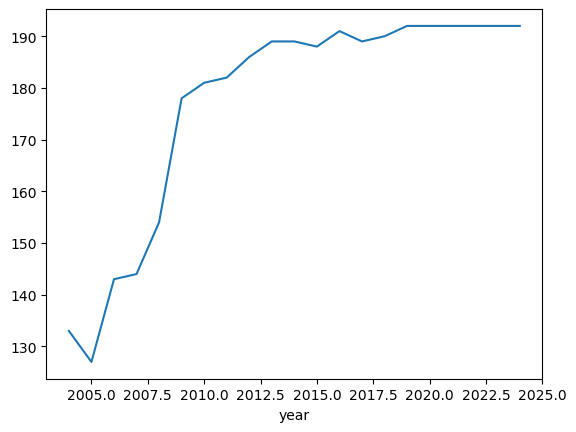

In [114]:
full_df.groupby('year').size().plot()

Plot turnover - does it look reasonable?

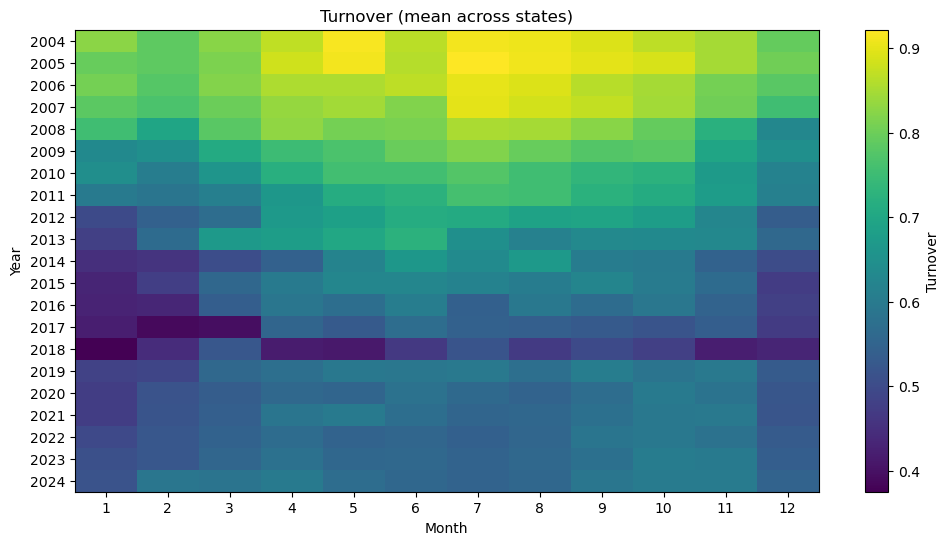

In [115]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = full_df.groupby(['year', 'month'])['turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Turnover (mean across states)")
plt.show()

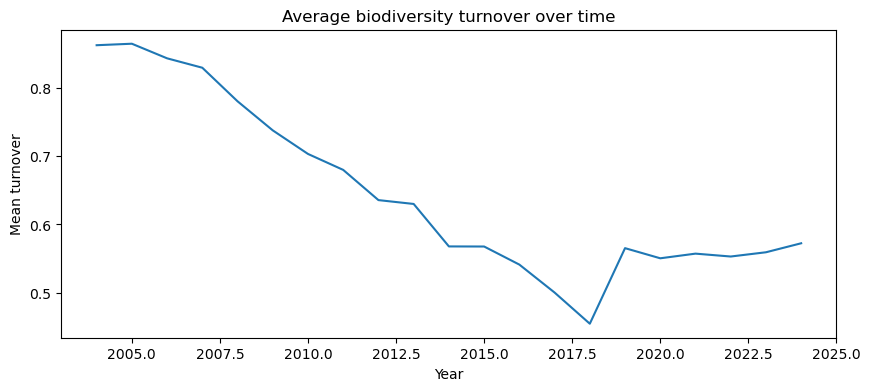

In [116]:
yearly = full_df.groupby('year')['turnover'].mean()

plt.figure(figsize=(10,4))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Mean turnover")
plt.title("Average biodiversity turnover over time")
plt.show()

Create binary 'biodiversity anomaly' outcome feature for classification model

1. compute baseline for state and month

In [117]:
# import pandas as pd
# full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

In [118]:
baseline = full_df.groupby(['state','month']).agg(
    mean_richness=('n_species','mean'),
    std_richness=('n_species','std')
).reset_index()

full_df = full_df.merge(baseline, on=['state','month'])

full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover,mean_richness,std_richness
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,2.333333,0.612179,0.833333,355.0,2.550228,93.0,0.178926,0.821074,231.428571,114.674135
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,2.000000,0.121404,1.333333,274.0,2.437751,108.0,0.202020,0.797980,276.900000,185.252005
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,0.000000,-0.483792,1.666667,815.0,2.911158,176.0,0.170146,0.829854,438.238095,290.009121
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,0.000000,-0.698102,1.666667,658.0,2.818226,197.0,0.111498,0.888502,743.523810,497.637581
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,0.000000,-0.067915,1.500000,914.0,2.960946,223.0,0.084793,0.915207,1135.380952,754.805039


2. Control for observation effort and year trend (with regression residuals)

In [119]:
# import statsmodels.api as sm

# X = sm.add_constant(full_df['log_n_obs']) # Creates dataframe of 1s (intercept) and log observations
# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [120]:
# # per-state trends

import statsmodels.api as sm

# Create design matrix
X = pd.get_dummies(full_df['state'], drop_first=True)

X['log_n_obs'] = full_df['log_n_obs']
# X['year'] = full_df['year']
full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
full_df['year_sq'] = full_df['year_centered'] ** 2
X['year_centered'] = full_df['year_centered']
X['year_sq'] = full_df['year_sq']

X = X.astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit model (richness)
model = sm.OLS(full_df['n_species'], X).fit()

full_df['expected_richness'] = model.predict(X)
full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

# Fit model (turnover)
model = sm.OLS(full_df['turnover'], X).fit()

full_df['expected_turnover'] = model.predict(X)
full_df['residual_turnover'] = full_df['turnover'] - full_df['expected_turnover']

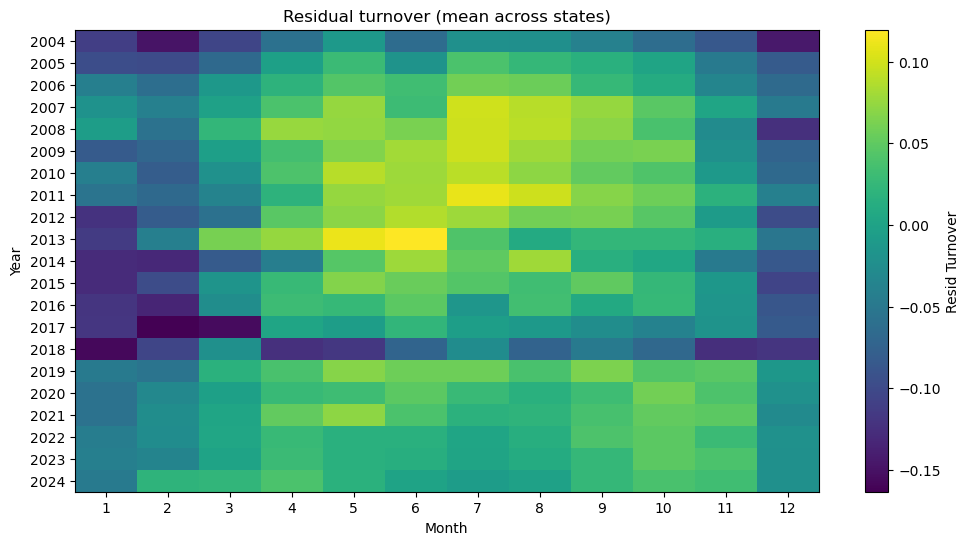

In [121]:
pivot = full_df.groupby(['year', 'month'])['residual_turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Resid Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Residual turnover (mean across states)")
plt.show()

In [122]:
# non-linear model

# import statsmodels.api as sm

# full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
# full_df['year_sq'] = full_df['year_centered'] ** 2

# X = full_df[['log_n_obs', 'year_centered', 'year_sq']]
# X = sm.add_constant(X)

# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [123]:
import numpy as np
full_df['sp_per_obs'] = np.log(full_df['n_species']) - np.log(full_df['n_obs'])

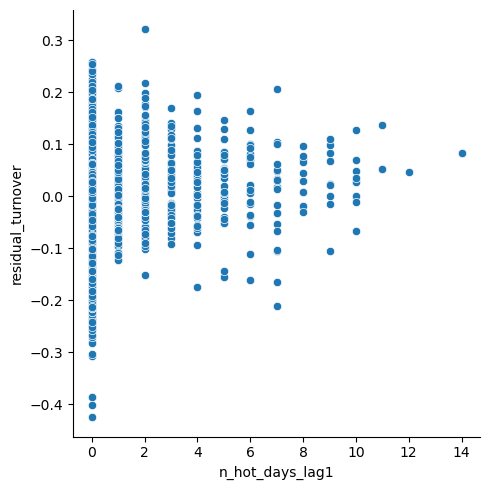

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_lag1',
            y='residual_turnover')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

3. Standardise residuals per state and month

In [125]:
full_df['residual_z'] = full_df.groupby(['state','month'])['residual'].transform(
    lambda x: (x - x.mean()) / x.std()
)

full_df['turnover_residual_z'] = full_df.groupby(['state','month'])['residual_turnover'].transform(
    lambda x: (x - x.mean()) / x.std()
)

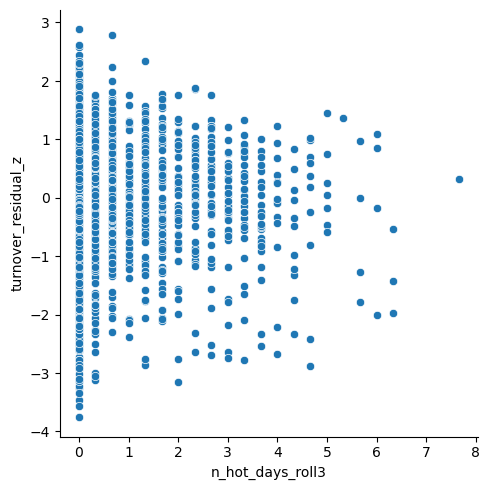

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_roll3',
            y='turnover_residual_z')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

4. Define binary anomaly  

interpretation:  
1 = biodiversity is unusually LOW for this state/month, given effort  
0 = normal or high biodiversity  

(or fine tune the threshold:  
-0.5 → more sensitive  
-1.0 → standard  
-1.5 → only extreme events
)

In [127]:
full_df['biodiversity_anomaly_standard'] = (full_df['residual_z'] < -1).astype(int)
full_df['biodiversity_anomaly_sensitive'] = (full_df['residual_z'] < -0.5).astype(int)
full_df['biodiversity_anomaly_conservative'] = (full_df['residual_z'] < -1.5).astype(int)

And for residual_turnover_z, higher values are 'bad':  

0 → expected turnover  
/>0 → higher-than-expected change  
< 0 → lower-than-expected change (more stable than expected)  

Use threshold based on quantiles in data - top 25% most extreme ecological change months

In [128]:
threshold = full_df['turnover_residual_z'].quantile(0.75)
full_df['high_turnover'] = (full_df['turnover_residual_z'] > threshold).astype(int)

In [129]:
full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,residual,expected_turnover,residual_turnover,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-148.774393,0.952479,-0.131405,-1.339518,1.121782,-2.265966,0,0,0,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-84.272976,0.955461,-0.157481,-0.930997,1.401059,-2.212807,0,0,0,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-224.619172,0.942909,-0.113055,-1.532704,0.196204,-2.163934,0,0,0,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-162.719972,0.945373,-0.056872,-1.206001,-0.703810,-1.327739,0,1,0,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-199.531103,0.941589,-0.026382,-1.410659,-0.798810,-0.562096,0,1,0,0


In [130]:
full_df.value_counts('biodiversity_anomaly_standard')

biodiversity_anomaly_standard
0    3151
1     565
Name: count, dtype: int64

In [131]:
full_df.value_counts('biodiversity_anomaly_sensitive')

biodiversity_anomaly_sensitive
0    2483
1    1233
Name: count, dtype: int64

In [132]:
full_df.value_counts('biodiversity_anomaly_conservative')

biodiversity_anomaly_conservative
0    3545
1     171
Name: count, dtype: int64

In [133]:
full_df.value_counts('high_turnover')

high_turnover
0    2787
1     929
Name: count, dtype: int64

plot biodiversity residuals over time

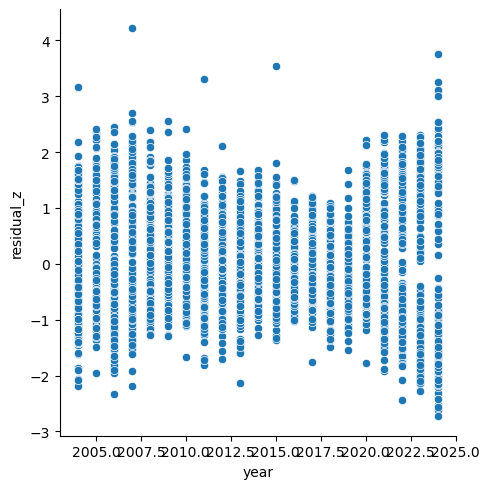

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='residual_z')
plt.show();

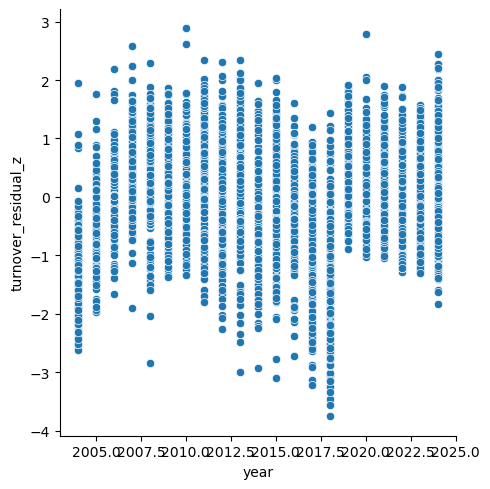

In [135]:
sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='turnover_residual_z')
plt.show();

Double check that lagged variable calculations worked correctly

In [136]:
full_df.loc[full_df['state'].isin(['Bayern', 'Berlin'])][['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']].groupby('state').head(3)

,state,monthyear,temp_anom_z,temp_anom_z_lag1
250,Bayern,1_2004,-0.484201,-0.255672
251,Bayern,2_2004,0.256806,-0.484201
252,Bayern,3_2004,-0.746567,0.256806
500,Berlin,1_2004,-0.731760,-0.016205
501,Berlin,2_2004,0.282089,-0.731760
502,Berlin,3_2004,0.109810,0.282089


Looks good - check if Jan lagged values are from December in previous year

In [137]:
(full_df.loc[(full_df['state'].isin(['Bayern', 'Berlin'])) 
            & (full_df['monthyear'].isin(['12_2004', '1_2005']))]
            [['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']]
            .groupby('state')
            .head(3))

,state,monthyear,temp_anom_z,temp_anom_z_lag1
261,Bayern,12_2004,-0.890507,-0.991200
262,Bayern,1_2005,0.008640,-0.890507
511,Berlin,12_2004,-0.136432,-0.731508
512,Berlin,1_2005,0.646846,-0.136432


Looks good!

Circular encoding of months  
(so that December (12) and January (1) are not interpreted as 11 months apart from each other)  

What This Achieves  
1. Cyclic continuity:  
- December → January is smooth, not “jumping” from 12 → 1  
2. Numeric representation:  
- Each month gets two numeric features  
- Model can now learn patterns like “winter months” or “summer months” continuously  
3. Avoids artificial ordering:  
- Tree-based models or linear models now handle seasonality correctly  

In [138]:
from numpy import pi, sin, cos

full_df['month_sin'] = sin(2*pi * full_df['month'] / 12)
full_df['month_cos'] = cos(2*pi * full_df['month'] / 12)

Now re-base the year to 0

In [139]:
full_df['year_offset'] = full_df['year'] - min(full_df['year'])

In [140]:
full_df

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-1.339518,1.121782,-2.265966,0,0,0,0,5.000000e-01,8.660254e-01,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.930997,1.401059,-2.212807,0,0,0,0,8.660254e-01,5.000000e-01,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-1.532704,0.196204,-2.163934,0,0,0,0,1.000000e+00,6.123234e-17,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-1.206001,-0.703810,-1.327739,0,1,0,0,8.660254e-01,-5.000000e-01,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-1.410659,-0.798810,-0.562096,0,1,0,0,5.000000e-01,-8.660254e-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3711,Thüringen,8_2024,2024,8,19.984138,30.950001,72.899994,2,2,18.361685,...,-2.386204,-1.488965,-1.184104,1,1,0,0,-8.660254e-01,-5.000000e-01,20
3712,Thüringen,9_2024,2024,9,15.468820,30.500000,88.400002,1,2,14.538055,...,-2.348772,-2.071312,-0.338740,1,1,1,0,-1.000000e+00,-1.836970e-16,20
3713,Thüringen,10_2024,2024,10,11.061694,18.700001,62.299999,0,1,10.015421,...,-2.462351,-1.799099,-0.430616,1,1,1,0,-8.660254e-01,5.000000e-01,20
3714,Thüringen,11_2024,2024,11,4.483958,13.750000,53.499996,0,1,5.154050,...,-2.718522,-1.646196,1.294947,1,1,1,1,-5.000000e-01,8.660254e-01,20


Save full_df - ready for model pipeline

In [141]:
full_df.to_parquet('../Data/Processed/full_df.parquet')

In [142]:
full_df.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,sp_per_obs,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
54,Baden-Württemberg,9_2008,2008,9,12.307972,25.884499,66.900002,0,2,14.722257,...,-2.048189,-1.185517,0.945178,1,1,0,1,-1.000000e+00,-1.836970e-16,4
682,Berlin,3_2019,2019,3,6.877352,16.850000,69.699997,0,3,4.696254,...,-2.830516,-0.177411,0.644056,0,0,0,0,1.000000e+00,6.123234e-17,15
925,Brandenburg,7_2020,2020,7,18.590054,28.350000,44.399998,0,0,19.887789,...,-2.157115,1.339047,-0.425386,0,0,0,0,-5.000000e-01,-8.660254e-01,16
1383,Hessen,3_2004,2004,3,4.157497,18.062000,42.300003,0,1,4.997900,...,-1.602635,1.244519,-1.137726,0,0,0,0,1.000000e+00,6.123234e-17,0
2058,Niedersachsen,10_2018,2018,10,11.850672,25.799999,35.299999,0,0,11.116194,...,-2.798388,0.018741,-2.220529,0,0,0,0,-8.660254e-01,5.000000e-01,14
472,Bayern,9_2022,2022,9,12.762013,25.799999,108.099991,0,2,14.574447,...,-2.909751,0.610014,-0.910331,0,0,0,0,-1.000000e+00,-1.836970e-16,18
3216,Sachsen-Anhalt,4_2022,2022,4,8.410348,20.950001,38.900002,0,2,9.727163,...,-1.955651,-1.099086,0.440198,1,1,0,0,8.660254e-01,-5.000000e-01,18
998,Bremen,5_2009,2009,5,13.327004,24.118000,50.900002,0,0,13.196730,...,-1.739748,0.343004,-0.975947,0,0,0,0,5.000000e-01,-8.660254e-01,5
1034,Bremen,8_2012,2012,8,18.408054,33.018002,51.000000,1,0,18.191109,...,-0.739540,0.706986,-1.418753,0,0,0,0,-8.660254e-01,-5.000000e-01,8
2276,Nordrhein-Westfalen,12_2015,2015,12,7.908266,13.450001,49.000000,0,0,3.044404,...,-3.401318,0.071640,-1.545769,0,0,0,0,-2.449294e-16,1.000000e+00,11
